## 案例: 电信客户流失分析.

目的:

    1. 演示逻辑回归的相关操作, 主要是: 二分法(流失, 不流失)
    2. 演示逻辑回归的评估操作, 主要是: 混淆矩阵, 准确率, 召回率, F1值, ROC曲线, AUC值, 分类评估报告(了解)

#### 导包

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
#  准确率           精确率            召回率        F1值        roc曲线          分类评估报告
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

#### 1. 定义函数，演示：数据的预处理

In [22]:
def dm01_data_preprocess():
    # 1. 读取csv文件，获取到df对象
    churn_df = pd.read_csv('./data/churn.csv')
    
    # 2. 查看（处理前）的数据集
    # churn_df.info()
    # print(churn_df.head(5))
    
    # 3. 因为Churn和gender列是字符串，所以需要进行one-hot编码（热编码处理）
    # pd.get_dummies()是 pandas 专门用于实现one-hot 编码（独热编码） 的函数，
    # 核心作用是把分类变量（尤其是字符串 / 离散型的分类列） 转换成机器学习模型能识别的数值型特征（0/1）。
    churn_df = pd.get_dummies(churn_df, columns=['Churn', 'gender'])
    
    # 4. 查看（处理后）的数据集
    # churn_df.info()
    # print(churn_df.head(5))
    
    # 5. 删除one-hot处理后，冗余的列
    # 参1: 要删除的列. 参2: 1表示删除列，0表示删除行   参3: inplace=True表示直接修改原数据.
    churn_df.drop(['Churn_No', 'gender_Male'], axis=1, inplace=True)
    # churn_df.info()
    # print(churn_df.head(5))
    
    # 6. 修改列名，将Churn_Yes -> flag，充当标签列
    churn_df.rename(columns={'Churn_Yes': 'flag'}, inplace=True)
    churn_df.info()
    print(churn_df.head(5))     # False -> 不流失，True -> 流失
    
    # 7. 查看数据值的分布
    print(churn_df.flag.value_counts())     # False:5174, True:1869     不均衡

#### 2. 定义函数，演示：数据的可视化

In [23]:
def dm02_data_visualization():
    # 1. 读取csv文件，获取到df对象
    churn_df = pd.read_csv('./data/churn.csv')
    
    # 2. 对object类型的列（数据）做one-hot编码处理
    churn_df = pd.get_dummies(churn_df, columns=['Churn', 'gender'])
    
    # 3. 删除one-hot处理后，冗余的列
    # 参1: 要删除的列. 参2: 1表示删除列，0表示删除行   参3: inplace=True表示直接修改原数据.
    churn_df.drop(['Churn_No', 'gender_Male'], axis=1, inplace=True)
    
    # 4. 修改列名，将Churn_Yes -> flag，充当标签列
    churn_df.rename(columns={'Churn_Yes': 'flag'}, inplace=True)
    
    # 5. 查看数据值的分布.
    print(churn_df.flag.value_counts())     # False: 5174, True: 1869
    
    # 6. 查看列名, 方便我们一会儿抽取 特征.
    # 列名为: ['Partner_att', 'Dependents_att', 'landline', 'internet_att', 'internet_other', 'StreamingTV', 'StreamingMovies', 'Contract_Month',Contract_1YR', 'PaymentBank', 'PaymentCreditcard', 'PaymentElectronic', 'MonthlyCharges', 'TotalCharges', 'flag', 'gender_Female']
    print(churn_df.columns)
    
    # 7. 数据的可视化，绘制计数柱状图
    # 参1: 数据集, 参2: x轴的列名(月度会员), 
    # 参3: hue表示分组, 根据分组进行绘制, 这里是: 是否流失(False->不流失, True->流失).
    sns.countplot(data=churn_df, x='Contract_Month', hue='flag')
    plt.show()

#### 3. 定义函数，演示：逻辑回归算法的模型训练，预测，评估

In [26]:
def dm03_logistic_regression():
     # 1. 加载数据集
     churn_df = pd.read_csv('./data/churn.csv')
    
     # 2. 数据的预处理
     # 2.1 对object类型的列（数据）做one-hot编码处理
     churn_df = pd.get_dummies(churn_df, columns=['Churn', 'gender'])
     # 2.2 删除one-hot处理后，冗余的列
     # 参1: 要删除的列. 参2: 1表示删除列，0表示删除行   参3: inplace=True表示直接修改原数据.
     churn_df.drop(['Churn_No', 'gender_Male'], axis=1, inplace=True)
     # 2.3 修改列名，将Churn_Yes -> flag，充当标签列
     churn_df.rename(columns={'Churn_Yes': 'flag'}, inplace=True)
     # 2.4 提取特征列和标签列
     # x 的特征列：月度会员，是否有互联网服务，是否是电子支付
     x = churn_df[['Contract_Month', 'internet_other', 'PaymentElectronic']]
     y = churn_df['flag']       # False -> 不流失，True -> 流失
     # 2.5 划分训练集和测试集
     x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=23)
     
     # 3. 特征工程（eg：特征提取，特征预处理 -> 归一化，标准化...），暂不处理
     
     # 4. 模型训练
     # 4.1 创建（逻辑回归）模型对象
     estimator = LogisticRegression()
     # 4.2 模型训练
     estimator.fit(x_train, y_train)
     
     # 5. 模型预测
     y_pred = estimator.predict(x_test)
     print(f'预测值为：{y_pred}')
     
     # 6. 模型评估
     print(f'准确率：{estimator.score(x_test, y_test)}')
     print(f'准确率：{accuracy_score(y_test, y_pred)}')
     
     print(f'精确率：{precision_score(y_test, y_pred)}')
     print(f'召回率：{recall_score(y_test, y_pred)}')
     print(f'F1值：{f1_score(y_test, y_pred)}')
     
     # macro avg: 宏平均, 即: 不考虑样本权重, 直接求平均. 适用于: 数据均衡的情况.
     # weighted avg: 样本权重平均, 即: 考虑样本权重, 求平均. 适用于: 数据不均衡的情况.
     print(f'分类评估报告：\n{classification_report(y_test, y_pred)}')

#### 4. 测试

flag
False    5174
True     1869
Name: count, dtype: int64
Index(['Partner_att', 'Dependents_att', 'landline', 'internet_att',
       'internet_other', 'StreamingTV', 'StreamingMovies', 'Contract_Month',
       'Contract_1YR', 'PaymentBank', 'PaymentCreditcard', 'PaymentElectronic',
       'MonthlyCharges', 'TotalCharges', 'flag', 'gender_Female'],
      dtype='object')


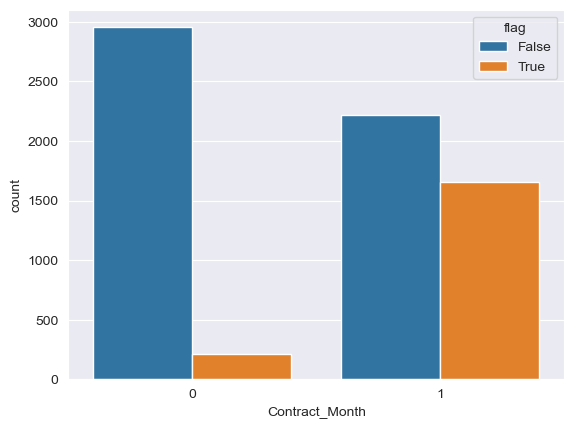

预测值为：[False False  True ... False  True False]
准确率：0.7679205110007097
准确率：0.7679205110007097
精确率：0.5807692307692308
召回率：0.4092140921409214
F1值：0.48012718600953896
分类评估报告：
              precision    recall  f1-score   support

       False       0.81      0.90      0.85      1040
        True       0.58      0.41      0.48       369

    accuracy                           0.77      1409
   macro avg       0.70      0.65      0.67      1409
weighted avg       0.75      0.77      0.75      1409



In [27]:
if __name__ == '__main__':
    # dm01_data_preprocess()
    dm02_data_visualization()
    dm03_logistic_regression()